# Sanity check: does the differentiable fine-tuning work?

Minimal synthetic datasets and formulas where the "correct" threshold / time-interval is known by construction, so we can directly check whether `stlrocket.tuning.finetune_formula` moves parameters in the right direction and improves true (hard-threshold) F1 -- not just the soft surrogate it actually optimizes.

Three toys:
1. Atom threshold only (no temporal operator).
2. `Eventually[a,b]` window position.
3. `Globally[a,b]` window + threshold jointly.

`finetune_formula` takes no smoothing hyperparameters. The LSE temperature and the acceptance-sigmoid width are derived from the robustness spread of the starting formula, and the time-mask steepness from the signal length -- each is a scale in the units of a measured quantity, so a value hand-tuned on one formula is wrong for another whose robustness spans a different order of magnitude. `log["temps"]` records what was derived.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, for the local (non pip-installed) stlrocket package

import numpy as np
import matplotlib.pyplot as plt
from torcheck.stl import Atom, Eventually, Globally

from stlrocket.tuning import finetune_formula
from stlrocket.evaluation import evaluate_global

np.random.seed(0)

## Toy 1: atom threshold only

Two classes, one variable, constant-ish signal: `hi` around `+5`, `lo` around `-5`. The true separating threshold is `0`. We start from a deliberately bad threshold (`-8`, so `x_0 >= -8` is trivially true for almost everyone) and check that fine-tuning moves it toward `0` and improves F1 for target class `hi`.

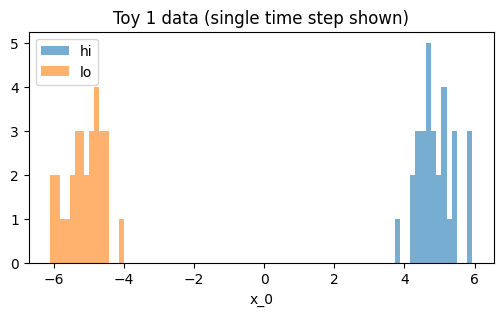

In [27]:
np.random.seed(0)
N, T = 60, 10
x_hi = 5 + 0.5 * np.random.randn(N // 2, 1, T)
x_lo = -5 + 0.5 * np.random.randn(N // 2, 1, T)
X1 = np.concatenate([x_hi, x_lo], axis=0).astype(np.float32)
y1 = np.array(["hi"] * (N // 2) + ["lo"] * (N // 2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(X1[y1 == "hi", 0, 0], bins=15, alpha=0.6, label="hi")
ax.hist(X1[y1 == "lo", 0, 0], bins=15, alpha=0.6, label="lo")
ax.set_xlabel("x_0"); ax.legend(); ax.set_title("Toy 1 data (single time step shown)")
plt.show()

In [28]:
phi1_bad = Atom(var_index=0, threshold=-8.0, lte=False)  # x_0 >= -8, trivially true

f1_before = evaluate_global({"hi": phi1_bad}, X1, y1)["hi"]["f1"]
phi1_tuned, log1 = finetune_formula(phi1_bad, X1, y1, "hi", n_steps=300)
f1_after = evaluate_global({"hi": phi1_tuned}, X1, y1)["hi"]["f1"]

print(f"threshold: {phi1_bad.threshold} -> {phi1_tuned.threshold:.3f}")
print(f"F1:        {f1_before:.3f} -> {f1_after:.3f}")
print(f"derived:   {log1['temps']}")

threshold: -8.0 -> -3.898
F1:        0.667 -> 1.000
derived:   {'beta_lse': 1.0120817490439247, 'c_mask': 2.5, 'accept_temp': 2.470156192779541, 'mask_eps': 0.001, 'rho_iqr': 9.880624771118164}


## Toy 2: `Eventually[a,b]` window position

Two classes with a 3-step spike (`x_0 += 5`) at different times: `early` at `t=3..5`, `late` at `t=12..14`. Baseline is near-zero noise. Target class is `early`; the true window is `[3,5]`.

We start from `F[12,14](x_0 >= 3)` -- the window for the *other* class's spike, so `F1` for `early` starts at `nan` (nobody satisfies it). This is a harder test than Toy 1: the window needs to move a long way with (initially) zero overlap with the correct interval.

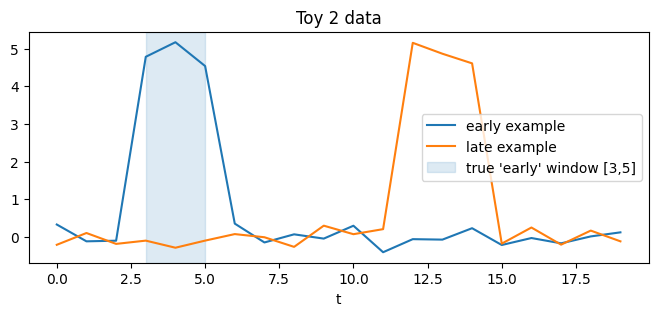

In [29]:
np.random.seed(1)
N, T = 60, 20

def make_spike_series(spike_start):
    x = 0.2 * np.random.randn(N // 2, 1, T)
    x[:, 0, spike_start:spike_start + 3] += 5.0
    return x

x_early = make_spike_series(3)
x_late = make_spike_series(12)
X2 = np.concatenate([x_early, x_late], axis=0).astype(np.float32)
y2 = np.array(["early"] * (N // 2) + ["late"] * (N // 2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X2[0, 0], label="early example")
ax.plot(X2[N // 2, 0], label="late example")
ax.axvspan(3, 5, color="C0", alpha=0.15, label="true 'early' window [3,5]")
ax.set_xlabel("t"); ax.legend(); ax.set_title("Toy 2 data")
plt.show()

In [30]:
phi2_bad = Eventually(
    Atom(var_index=0, threshold=3.0, lte=False),
    unbound=False, right_unbound=False, left_time_bound=12, right_time_bound=14,
)

f1_before = evaluate_global({"early": phi2_bad}, X2, y2)["early"]["f1"]
phi2_tuned, log2 = finetune_formula(phi2_bad, X2, y2, "early", n_steps=3000)
f1_after = evaluate_global({"early": phi2_tuned}, X2, y2)["early"]["f1"]

print(f"window:    [12,14] -> [{phi2_tuned.left_time_bound},{phi2_tuned.right_time_bound - 1}]   (true window is [3,5])")
print(f"threshold: 3.0 -> {phi2_tuned.child.threshold:.3f}")
print(f"F1:        {f1_before} -> {f1_after:.3f}")
print(f"derived:   {log2['temps']}")

window:    [12,14] -> [3,6]   (true window is [3,5])
threshold: 3.0 -> 1.214
F1:        nan -> 1.000
derived:   {'beta_lse': 2.004586222025527, 'c_mask': 2.5, 'accept_temp': 1.2471401691436768, 'mask_eps': 0.001, 'rho_iqr': 4.988560676574707}


## Toy 3: `Globally[a,b]` window + threshold jointly

`stable` never exceeds `~0` (small noise); `spiky` has one `+3` excursion at a random time in `[5,15]`. The true explanation for `stable` is "stays below ~1.5 throughout `[5,15]`" -- i.e. the *full* window `[5,15]`.

We start from `G[5,6](x_0 <= 1)`: the right starting edge but a window one step wide, so it sees almost none of the interval that separates the classes. Both the window and the threshold have to move.

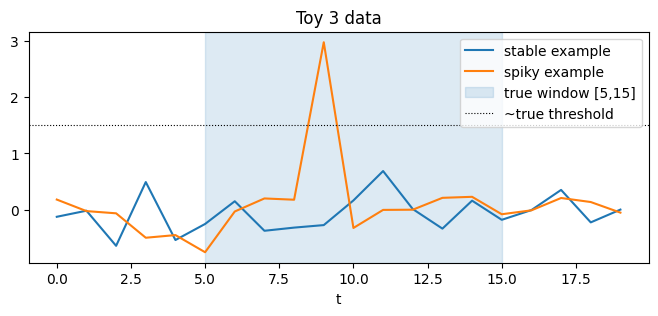

In [31]:
np.random.seed(2)
N, T = 60, 20

x_stable = 0.3 * np.random.randn(N // 2, 1, T)
x_spiky = 0.3 * np.random.randn(N // 2, 1, T)
for i in range(N // 2):
    t = np.random.randint(5, 16)
    x_spiky[i, 0, t] += 3.0
X3 = np.concatenate([x_stable, x_spiky], axis=0).astype(np.float32)
y3 = np.array(["stable"] * (N // 2) + ["spiky"] * (N // 2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X3[0, 0], label="stable example")
ax.plot(X3[N // 2, 0], label="spiky example")
ax.axvspan(5, 15, color="C0", alpha=0.15, label="true window [5,15]")
ax.axhline(1.5, color="black", linestyle=":", linewidth=0.8, label="~true threshold")
ax.set_xlabel("t"); ax.legend(); ax.set_title("Toy 3 data")
plt.show()

In [32]:
phi3_bad = Globally(
    Atom(var_index=0, threshold=1.0, lte=True),
    unbound=False, right_unbound=False, left_time_bound=5, right_time_bound=6,
)

f1_before = evaluate_global({"stable": phi3_bad}, X3, y3)["stable"]["f1"]
phi3_tuned, log3 = finetune_formula(phi3_bad, X3, y3, "stable", n_steps=3000)
f1_after = evaluate_global({"stable": phi3_tuned}, X3, y3)["stable"]["f1"]

print(f"threshold: 1.0 -> {phi3_tuned.child.threshold:.3f}")
print(f"window:    [5,6] -> [{phi3_tuned.left_time_bound},{phi3_tuned.right_time_bound - 1}]   (true window is [5,15])")
print(f"F1:        {f1_before:.3f} -> {f1_after:.3f}")
print(f"derived:   {log3['temps']}")

threshold: 1.0 -> 1.050
window:    [5,6] -> [5,15]   (true window is [5,15])
F1:        0.698 -> 0.983
derived:   {'beta_lse': 34.43966925862366, 'c_mask': 2.5, 'accept_temp': 0.07259070873260498, 'mask_eps': 0.001, 'rho_iqr': 0.2903628349304199}


## Toy 4: nested temporal operators


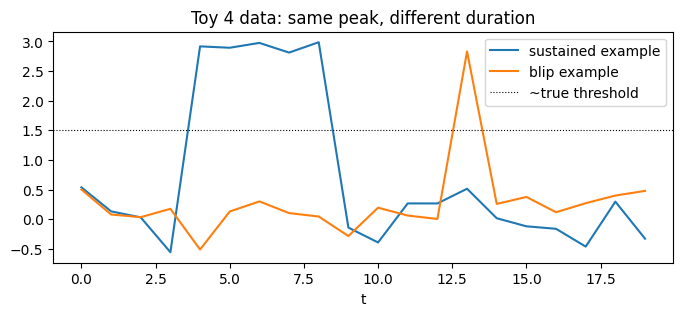

F[0,17](x_0 >= 1.0):  F1 = 0.667
F[0,17](x_0 >= 1.5):  F1 = 0.667
F[0,17](x_0 >= 2.0):  F1 = 0.667


In [33]:
np.random.seed(3)
N, T = 60, 20

x_sustained = 0.3 * np.random.randn(N // 2, 1, T)
x_blip = 0.3 * np.random.randn(N // 2, 1, T)
for i in range(N // 2):
    start = np.random.randint(4, 14)
    x_sustained[i, 0, start:start + 5] += 3.0      # 5-step plateau
    x_blip[i, 0, np.random.randint(4, 16)] += 3.0  # same height, 1 step
X4 = np.concatenate([x_sustained, x_blip], axis=0).astype(np.float32)
y4 = np.array(["sustained"] * (N // 2) + ["blip"] * (N // 2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X4[0, 0], label="sustained example")
ax.plot(X4[N // 2, 0], label="blip example")
ax.axhline(1.5, color="black", linestyle=":", linewidth=0.8, label="~true threshold")
ax.set_xlabel("t"); ax.legend(); ax.set_title("Toy 4 data: same peak, different duration")
plt.show()

# A single Eventually cannot tell them apart at any threshold.
for thr in [1.0, 1.5, 2.0]:
    flat = Eventually(Atom(var_index=0, threshold=thr, lte=False),
                      left_time_bound=0, right_time_bound=17)
    print(f"F[0,17](x_0 >= {thr}):  F1 = {evaluate_global({'sustained': flat}, X4, y4)['sustained']['f1']:.3f}")

In [34]:
phi4_bad = Eventually(
    Globally(
        Atom(var_index=0, threshold=1.5, lte=False),
        unbound=False, right_unbound=False, left_time_bound=0, right_time_bound=1,
    ),
    unbound=False, right_unbound=False, left_time_bound=0, right_time_bound=15,
)

f1_before = evaluate_global({"sustained": phi4_bad}, X4, y4)["sustained"]["f1"]
phi4_tuned, log4 = finetune_formula(phi4_bad, X4, y4, "sustained", n_steps=3000)
f1_after = evaluate_global({"sustained": phi4_tuned}, X4, y4)["sustained"]["f1"]

print(f"formula:   {phi4_bad}")
print(f"       ->  {phi4_tuned}")
print(f"threshold: 5.0 -> {phi4_tuned.child.child.threshold:.3f}   (true threshold is ~1.5)")
print(f"outer:     [0,15] -> [{phi4_tuned.left_time_bound},{phi4_tuned.right_time_bound - 1}]")
print(f"inner:     [0,2] -> [{phi4_tuned.child.left_time_bound},{phi4_tuned.child.right_time_bound - 1}]")
print(f"F1:        {f1_before} -> {f1_after:.3f}")
print(f"derived:   {log4['temps']}")

KeyboardInterrupt: 

## Real pipeline: STLRocket on BasicMotions, then tune the global explanations

The toys above are synthetic and single-variable. Here we run the actual STLRocket pipeline end to end -- sample a formula bank, fit the LASSO classifier, build local + global explanations the normal way (`build_global_explanations`, unmodified) -- and then fine-tune each class's *assembled global formula* for F1, using the same `X_tr, y_tr` it was built from.

This is deliberately **not** the local-explanation insertion point explored elsewhere in this project (tuning after `greedy_precise_picks`, or inside `reparametrize_formula`): those either trade `mean_local_precision` against `global_macro_f1_test`, or were only tested on one dataset before turning out to hurt others (ERing, Epilepsy). Tuning the assembled global formula is the one insertion point that measured a **consistent, non-negative** gain across datasets and seeds this session (BasicMotions, Epilepsy, Cricket; never negative, and zero-change rather than harmful when train F1 was already saturated, e.g. ERing). It leaves `mean_local_precision` completely unaffected, since the per-instance locals reported for that metric are rebuilt independently and never see the tuned global.

The `accept_only_if_better` gate in `finetune_formula` means this can only match or beat the baseline on the data it is tuned on -- any generalization gain on the held-out test set is not guaranteed by construction, only observed.

In [10]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

from stlrocket.config import ExperimentConfig
from stlrocket.data import load_dataset
from stlrocket.features import build_formula_bank
from stlrocket.classifier import train_classifier
from stlrocket.explanations import build_global_explanations
from stlrocket.evaluation import evaluate_global

DATASET = "BasicMotions"
DEPTH_MAX = 2      
N_FORMULAS = 10000 
SEED = 3

config = ExperimentConfig(
    dataset=DATASET, n_formulas=N_FORMULAS, depth_max=DEPTH_MAX,
    only_temporal=True, until_weight=0.0, cv=5,
    pool_size=10, precision_threshold=0.75,
    simplify_agreement=0.98, simplify_min_gain=0.0, simplify_decimals=1,
    n_run=1, base_seed=SEED, explain=True,
    output_dir="/tmp/stlrocket_toy_check", device="cpu",
)

X_tr, y_tr, X_te, y_te = load_dataset(DATASET)
print(f"{DATASET}: train {X_tr.shape}  test {X_te.shape}  classes {sorted(set(y_tr))}")

formulas, X_tr_feats, X_te_feats = build_formula_bank(X_tr, X_te, config, seed=SEED)
model = train_classifier(X_tr_feats, y_tr, config, seed=SEED)

global_per_class, locals_per_class, n_unique_per_class = build_global_explanations(
    X_te_feats, X_te, X_tr_feats, X_tr,
    model.coef_, model.intercept_, model, formulas, y_tr,
    pool_size=config.pool_size, precision_threshold=config.precision_threshold,
    simplify_agreement=config.simplify_agreement,
    simplify_min_gain=config.simplify_min_gain,
    simplify_decimals=config.simplify_decimals,
)

mean_local_precision = np.mean(
    [precision for rows in locals_per_class.values() for (_i, _phi, _picks, precision, _tp, _fp, _depth) in rows]
)
metrics_before = evaluate_global(global_per_class, X_te, y_te)

print(f"\nBEFORE tuning:")
print(f"  mean_local_precision  : {mean_local_precision:.4f}")
print(f"  global_macro_f1_test  : {metrics_before['macro_avg']['f1']:.4f}")
for cls, phi in global_per_class.items():
    print(f"    [{cls}] {phi}")

BasicMotions: train (40, 6, 100)  test (40, 6, 100)  classes [np.str_('badminton'), np.str_('running'), np.str_('standing'), np.str_('walking')]

BEFORE tuning:
  mean_local_precision  : 0.9908
  global_macro_f1_test  : 0.9355
    [standing] ( G[75,inf](x_0 <= 0.8) )
    [running] ( F[6,22](x_0 <= -6.6) )
    [walking] ( ( G(x_1 => -10.7) ) ∧ ( F[77,inf](x_1 => 3.0) ) )
    [badminton] ( F(x_0 => 25.2) )


In [11]:
# Tune each class's assembled global formula for F1, on the same train data it
# was built from -- no change anywhere else in the pipeline.
tuned_per_class = {}
tune_logs = {}
for cls, phi in global_per_class.items():
    phi_tuned, log = finetune_formula(phi, X_tr, y_tr, cls, n_steps=300, objective="f1")
    tuned_per_class[cls] = phi_tuned
    tune_logs[cls] = log

metrics_after = evaluate_global(tuned_per_class, X_te, y_te)

print(f"AFTER tuning:")
print(f"  mean_local_precision  : {mean_local_precision:.4f}   (unchanged -- locals are rebuilt independently, not touched here)")
print(f"  global_macro_f1_test  : {metrics_after['macro_avg']['f1']:.4f}"
      f"   (delta {metrics_after['macro_avg']['f1'] - metrics_before['macro_avg']['f1']:+.4f})")
n_accepted = sum(1 for log in tune_logs.values() if log["accepted"])
print(f"  {n_accepted}/{len(global_per_class)} tuned formulas accepted (improved train F1; kept original otherwise)\n")

for cls in global_per_class:
    before, after = global_per_class[cls], tuned_per_class[cls]
    changed = str(before) != str(after)
    f1_b = evaluate_global({cls: before}, X_te, y_te)[cls]["f1"]
    f1_a = evaluate_global({cls: after}, X_te, y_te)[cls]["f1"]
    print(f"  [{cls}] test F1 {f1_b:.3f} -> {f1_a:.3f}  (accepted={tune_logs[cls]['accepted']})")
    if changed:
        print(f"    was: {before}")
        print(f"    now: {after}")

AFTER tuning:
  mean_local_precision  : 0.9908   (unchanged -- locals are rebuilt independently, not touched here)
  global_macro_f1_test  : 0.9355   (delta +0.0000)
  3/4 tuned formulas accepted (improved train F1; kept original otherwise)

  [standing] test F1 1.000 -> 1.000  (accepted=True)
    was: ( G[75,inf](x_0 <= 0.8) )
    now: ( G[75,inf](x_0 <= 0.85) )
  [running] test F1 0.952 -> 0.952  (accepted=False)
  [walking] test F1 0.947 -> 0.947  (accepted=True)
    was: ( ( G(x_1 => -10.7) ) ∧ ( F[77,inf](x_1 => 3.0) ) )
    now: ( ( G(x_1 => -10.65) ) ∧ ( F[77,inf](x_1 => 2.95) ) )
  [badminton] test F1 0.842 -> 0.842  (accepted=True)
    was: ( F(x_0 => 25.2) )
    now: ( F(x_0 => 25.15) )
